# Event Mixer for MPS MC LHE Files

MPS samples can be equivalently produced by putting a number of SPS samples together, setting proper color flow parameters and also linage information.

Here, by using `pylhe` and `awkward` functionalities, we expect to conduct the mixing more efficiently.

In [16]:
from pylhe import *
import pylhe
import os
import numpy as np
import awkward as ak
from typing_extensions import List, Dict, Union, Optional, Tuple

Add an example: DPS $pp\rightarrow J/\psi+\Upsilon$ mixing from single $J/\psi$ and single $\Upsilon$ samples.

In [17]:
test_single_J_path = "/eos/user/c/chiw/JpsiJpsiUps/MC_samples/LHE/SPS-Jpsi/MC_Jpsi_block_00001.lhe"
test_single_Y_path = "/eos/user/c/chiw/JpsiJpsiUps/MC_samples/LHE/SPS-Y/MC_Y_block_00001.lhe"
test_single_J = pylhe.read_lhe_with_attributes(test_single_J_path)
test_single_Y = pylhe.read_lhe_with_attributes(test_single_Y_path)
test_single_J_ak = pylhe.to_awkward(test_single_J)
test_single_Y_ak = pylhe.to_awkward(test_single_Y)

In [18]:
ak.type(test_single_J_ak)

ArrayType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['nparticles', 'pid', 'weight', 'scale', 'aqed', 'aqcd'], parameters={'__record__': 'EventInfo'}), ListType(RecordType([RecordType([NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['x', 'y', 'z', 't'], parameters={'__record__': 'Momentum4D'}), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64'), NumpyType('float64')], ['vector', 'id', 'status', 'mother1', 'mother2', 'color1', 'color2', 'm', 'lifetime', 'spin'], parameters={'__record__': 'Particle'}))], ['eventinfo', 'particles'], parameters={'__record__': 'Event'}), 1000, None)

## Implementation Steps

* Separate out the particles and event info;
* Reassign the color and lineage information of the particles to be mixed;
* Concatenate the particles;
* Rebuild the event by adding back the event info.

Will use as much awkward as possible to speed up the process.

To make it as generalized as possible, we will use such argument list for the core function:

* `sources:List[ak.Array[LHEEvent]]` - list of LHEEvent sources, each source as an awkward array of LHEEvent;
* `mix_recipe:List[int]` - a list of integers, same length as sources, indicating how many events to take from each source to mix into one event;
* `sources_count:Optional[List[int]]` - list of integers, same length as sources, indicating how many total events available in each source
  * if not provided, will use the length of each source as the count;
  * if at a different length with sources, will raise an error;
  * if not exactly multiples of the mix_recipe, will automatically floor the count to the largest multiple of the mix_recipe;
  * if exceeding the actual count of the source, automatically floor the count to the actual count of the source;

One note on the implementation: `reshape` is not directly supported by `awkward`, so we will use `flatten` and `unflatten` to achieve the same effect.

In [19]:
def get_available_final_events_ak(sources:List[ak.Array], mix_recipe:List[int], sources_count:Optional[List[int]]=None):
    """
    Returns the number of available final events for a given mix recipe.
    
    Parameters
    ----------
    sources : List[ak.Array]
        List of source arrays, where each array contains events from a different source.
    mix_recipe : List[int]
        Recipe for mixing, where each integer corresponds to the index of the source array.
    sources_count : Optional[List[int]]
        Optional list specifying how many events to take from each source. If None, all events are taken.
    
    Returns
    -------
    int
        Number of available final events.
    """
    # Check sources_count length matches sources length
    if sources_count is not None:
        if len(sources_count) != len(sources):
            raise ValueError("Length of sources_count must match length of sources.")
        else:
            # Properly handle the case where sources_count is provided
            sources_count = np.array(sources_count)
            sources_count_max = np.array([len(s) for s in sources])
            sources_count = np.minimum(sources_count, sources_count_max)
    else:
        # If sources_count is None, take all events from each source
        sources_count = np.array([len(s) for s in sources])
    
    # Use division to determine how many events can be obtained in the final product.
    mix_recipe = np.array(mix_recipe)
    max_product_count = np.min(sources_count / mix_recipe)
    
    return int(max_product_count)    

In [20]:
get_available_final_events_ak([test_single_J_ak, test_single_Y_ak], [2, 1], [100, 100])

50

In [21]:
def lhe_particle_2nd_dim_offset(particles:ak.Array, property:str, offset:np.array, keep_zeros:bool=True):
    """
    Offsets the specified property of particles by a given offset.
    This is meant for offsetting the color flow and lineage information of particles in LHE events, source-wise.

    Parameters
    ----------
    particles : ak.Array
        Array of particles from LHE events, organized in the "event_count*source_count*particle_count(var)" format.
    property : str
        The property of the particles to offset (e.g., "color1", "color2", "mother1", "mother2").
    offset : np.array
        Array of offsets for each source, should match the number of sources.
    keep_zeros : bool, optional
        If True, keeps the zero values in the property. If False, offsets all values including zeros. Default is True.
    
    Returns
    -------
    ak.Array
        The particles with the specified property offset by the given offsets.
        The "group-by-source" structure is preserved,
            meaning the first dimension corresponds to the event count,
            the second dimension corresponds to the source count.
    """
    # Check if the property exists in the particles
    if property not in particles.fields:
        raise ValueError(f"Property '{property}' not found in particles.")
    # Check if the offset is a 1D array and its length will not exceed the number of sources
    if not isinstance(offset, np.ndarray) or offset.ndim != 1:
        raise ValueError("Offset must be a 1D numpy array.")
    if len(offset) > ak.num(particles, axis=1)[0]:
        raise ValueError("Length of offset exceeds the number of sources in particles.")
    
    # Create a copy of the particles to modify
    modified_particles_array = []
    for i, offset_value in enumerate(offset):
        modified_particles = particles[:, i]
        if keep_zeros:
            modified_particles = ak.with_field(modified_particles, 
                                               ak.where(modified_particles[property] > 0,
                                                        modified_particles[property] + offset_value,
                                                        modified_particles[property]), 
                                               property)
        else:
            modified_particles = ak.with_field(modified_particles, 
                                               modified_particles[property] + offset_value, 
                                               property)
        # Stack back the modified particles, make sure to stack along axis=1
        if i == 0:
            modified_particles_array = modified_particles[:, np.newaxis]
        else:
            modified_particles_array = ak.concatenate([modified_particles_array, modified_particles[:, np.newaxis]], axis=1)
    # Return the modified particles array
    return modified_particles_array


def lhe_event_ak_mixer(sources:List[ak.Array], mix_recipe:np.array, sources_count:Optional[List[int]]=None):
    """
    Mixes multiple LHEEvent arrays according to a recipe.
    
    Parameters
    ----------
    sources : List[ak.Array]
        List of events to mix, same format as obtained via `pylhe.to_awkward`.
    mix_recipe : List[int]
        Recipe for mixing, where each integer corresponds to the index of the source array.
    sources_count : Optional[List[int]]
        Optional list specifying how many events to take from each source. If None, all events are taken.
    
    Returns
    -------
    ak.Array
        An ak array representing LHE events, same format as obtained via `pylhe.to_awkward`.
    """
    # Get the number of available final events
    if len(sources) != len(mix_recipe):
        raise ValueError("Length of sources must match length of mix_recipe.")
    if len(sources) != len(sources_count):
        raise ValueError("Length of sources must match length of sources_count.")
    
    available_final_events = get_available_final_events_ak(sources, mix_recipe, sources_count)

    # From the first source, take event info of first available_final_events to be used for mixing result.
    output_events_info = sources[0][0:available_final_events].eventinfo

    # Extract the particles from the events, truncated to suit the available_final_events and reshape to match the mix_recipe.
    source_particles_to_mix = []
    for i, source in enumerate(sources):
        source_particles = source.particles[0:(available_final_events * mix_recipe[i])]
        source_particles = ak.unflatten(source_particles, mix_recipe[i], axis=0)
        source_particles_to_mix.append(source_particles)
    source_particles_to_mix = ak.concatenate(source_particles_to_mix, axis=1)
    total_groups = np.sum(mix_recipe)
    modified_particles_array = []
    modified_particles = []

    # Handle the color flow information: offset the color flow indices by maximum color of the previous sources.
    color_flow_offset = np.zeros(total_groups, dtype=np.int32)
    for i in range(1, total_groups):
        max_color1 = ak.max(source_particles_to_mix[:, i-1].color1, axis=None)
        max_color2 = ak.max(source_particles_to_mix[:, i-1].color2, axis=None)
        color_flow_offset[i] = color_flow_offset[i-1] + max_color1 + max_color2 + 100
    # - Use the lhe_particle_2nd_dim_offset function to offset the color1 and color2 properties.
    source_particles_to_mix = lhe_particle_2nd_dim_offset(source_particles_to_mix, "color1", color_flow_offset, True)
    source_particles_to_mix = lhe_particle_2nd_dim_offset(source_particles_to_mix, "color2", color_flow_offset, True)

    # Handle lineage information: offset the lineage indices by the total number of particles in the corresponding event.
    # - Will have to assume that all events in each source have the same number of particles.
    lineage_offset = np.zeros(total_groups, dtype=np.int32)
    for i in range(1, total_groups):
        # Get the number of particles in the previous source's events.
        nparticles_previous = ak.num(source_particles_to_mix[:, i-1], axis=1)
        # Calculate the offset for the current source.
        lineage_offset[i] = lineage_offset[i-1] + ak.max(nparticles_previous, axis=None)
    source_particles_to_mix = lhe_particle_2nd_dim_offset(source_particles_to_mix, "mother1", lineage_offset, keep_zeros=True)
    source_particles_to_mix = lhe_particle_2nd_dim_offset(source_particles_to_mix, "mother2", lineage_offset, keep_zeros=True)

    # Further merge the particles into a single array, where each event contains the particles from all sources.
    mixed_particles = ak.flatten(source_particles_to_mix, axis=2)
    # - Bringing back the px, py, pz, and E fields to the particles.
    mixed_particles = ak.with_field(mixed_particles, mixed_particles.vector.px, "px")
    mixed_particles = ak.with_field(mixed_particles, mixed_particles.vector.py, "py")
    mixed_particles = ak.with_field(mixed_particles, mixed_particles.vector.pz, "pz")
    mixed_particles = ak.with_field(mixed_particles, mixed_particles.vector.e, "e")
    mixed_particles = ak.without_field(mixed_particles, "vector")
    # - Fix the nparticles in the event info to match the number of particles in the mixed particles.
    output_events_info = ak.with_field(output_events_info, ak.num(mixed_particles, axis=1), "nparticles")
    
    # Create the mixed awkward array with the mixed particles and the event info.
    mixed_events = ak.zip({
        "eventinfo": output_events_info,
        "particles": mixed_particles
    }, depth_limit=1, with_name="LHEEvent")
    # Return the mixed events.  
    return mixed_events

test_ak_mixer_events_ak = lhe_event_ak_mixer([test_single_J_ak, test_single_Y_ak], [2, 1], [100, 100])

In [22]:
ak.to_list(test_ak_mixer_events_ak[0].eventinfo)

{'pid': 89.0,
 'weight': 288.4803,
 'scale': 3.100766,
 'aqed': 0.00729927,
 'aqcd': 0.118,
 'nparticles': 12}

In [23]:
type(test_ak_mixer_events_ak[0].particles[0])

pylhe.awkward.ParticleRecord

Wonderful prototyping! Now try to output the mixed events to a LHE file and print it.

Ughh...looks like `pylhe` cannot just take `awkward.Array` as input, so we will need to convert it to an `awkward.Array` of `pylhe.LHEEvent`...manually.

In [24]:
type(ak.to_list(test_ak_mixer_events_ak[0].eventinfo))

dict

In [25]:
my_test_evt_info = LHEEventInfo(**ak.to_list(test_ak_mixer_events_ak[0].eventinfo))

In [26]:
my_test_particles = [LHEParticle(**p) for p in ak.to_list(test_ak_mixer_events_ak[0].particles)]

To convert an ak-particle into a pylhe-particle, we will have to convert the momentum of the particle from vector to individual floats, and then convert the particle into a pylhe-particle.

In [27]:
my_lhe_event = LHEEvent(
    eventinfo=my_test_evt_info,
    particles=my_test_particles
)

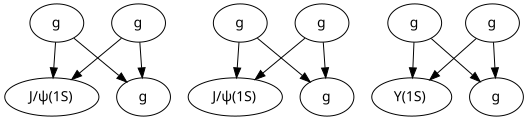

In [28]:
my_lhe_event

Beautifully done! Now we can write the mixed events to a LHE file.

In [31]:
def lhe_ak_to_lhe_file(evt_array: ak.Array, init_info: LHEInit):
    """
    Writes an awkward array of LHE events to a file using pylhe.
    
    Parameters
    ----------
    evt_array: ak.Array
        Array of LHE events, with fields "eventinfo" and "particles".
        "eventinfo" as a list of LHEEventInfo and "particles" as a list of LHEParticle.
    output_path : str
        Path to the output file.
    """
    # Create the LHEFile object with the init info and events
    lhe_events = [LHEEvent(eventinfo=LHEEventInfo(**ak.to_list(evt.eventinfo)),
                           particles=[LHEParticle(**p) for p in ak.to_list(evt.particles)])
                           for evt in evt_array]
    # Very careful! The input init info might not have "weightgroup" term.
    # - If it does not, we will add an empty weightgroup to the init info.
    tmp_raw_init = init_info.copy()
    if "weightgroup" not in tmp_raw_init.keys():
        tmp_raw_init["weightgroup"] = {}
    tmp_raw_init["nevents"] = len(evt_array)
    init_info = LHEInit(**tmp_raw_init)
    # Write the LHE events to the file
    return LHEFile(init_info, lhe_events)

# Example usage of the write function
my_lhe_file = lhe_ak_to_lhe_file(test_ak_mixer_events_ak, pylhe.read_lhe_init(test_single_J_path))
# Write the LHE file to disk
output_path = "mixed_lhe_events.lhe"
pylhe.write_lhe_file_path(my_lhe_file, output_path)

Haha! My beauty! Now everything is beautifully set, and we can perhaps do a bit performance check.